# Library

In [1]:
import numpy as np
import xarray as xr
import geopandas as gpd
import shapely.geometry as sgeom
import matplotlib.pyplot as plt
import pandas as pd

# Helper

In [2]:
# 10 data awal
def plot_eda_time_series_map(
    ds,
    var_name,
    n_data=10,
    time_dim="time",
    cmap="viridis",
    col_wrap=5,
    figsize=None,
    vmin=None,
    vmax=None,
    cbar_label=None
):

    # Validasi variabel
    if var_name not in ds.data_vars:
        raise ValueError(
            f"Variabel '{var_name}' tidak ditemukan. "
            f"Variabel tersedia: {list(ds.data_vars)}"
        )

    # Validasi dimensi waktu
    if time_dim not in ds[var_name].dims:
        raise ValueError(
            f"Dimensi '{time_dim}' tidak ditemukan pada variabel '{var_name}'. "
            f"Dimensi tersedia: {ds[var_name].dims}"
        )

    # Ambil n data pertama
    data_subset = ds[var_name].isel({time_dim: slice(0, n_data)})

    print(f"Nama variabel        : {var_name}")
    print(f"Shape data subset   : {data_subset.shape}")
    print(f"Jumlah data waktu   : {data_subset.sizes[time_dim]}")
    print(f"Dimensi             : {data_subset.dims}")

    # Ukuran otomatis jika tidak ditentukan
    if figsize is None:
        n_rows = (n_data + col_wrap - 1) // col_wrap
        figsize = (3 * col_wrap, 3 * n_rows)

    # Label colorbar otomatis
    if cbar_label is None:
        cbar_label = var_name

    # Plot
    data_subset.plot(
        col=time_dim,
        col_wrap=col_wrap,
        cmap=cmap,
        figsize=figsize,
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={
            "label": cbar_label
        }
    )

    plt.show()

    return 

# Load Dataset

In [3]:
ds = xr.open_dataset(
    "/kaggle/input/notebooks/andreh19/data-modis-merge/combined_chla_2014_2025.nc")

In [4]:
ds

<xarray.Dataset> Size: 356MB
Dimensions:  (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (time, lat, lon) float32 356MB ...
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

## 10 data awal

Nama variabel        : chlor_a
Shape data subset   : (10, 408, 432)
Jumlah data waktu   : 10
Dimensi             : ('time', 'lat', 'lon')


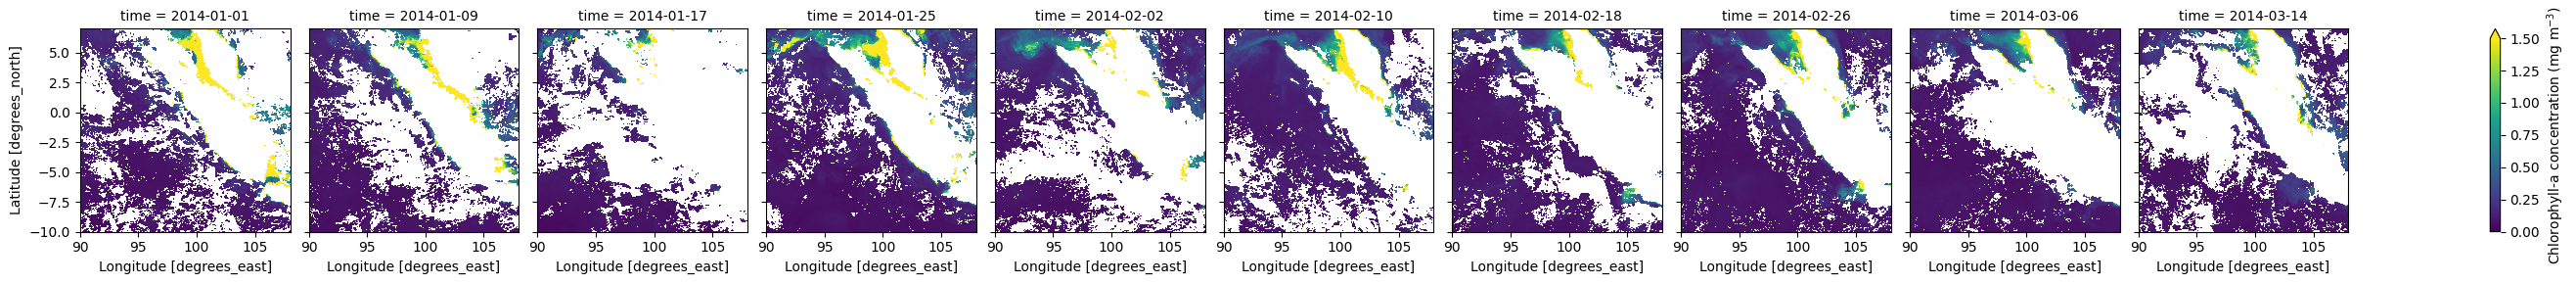

In [5]:
plot_eda_time_series_map(
    ds=ds,
    var_name="chlor_a",
    n_data=10,
    cmap="viridis",
    col_wrap=10,
    vmin=0,
    vmax=1.5,
    cbar_label="Chlorophyll-a concentration (mg m$^{-3}$)"
)

# Masking Data
Masking di sini bermaskud hanya untuk  mengambil area WPP 572

In [6]:
gdf = gpd.read_file("/kaggle/input/datasets/andreh19/peta-wpp572/WPP572.geojson")
gdf = gdf.to_crs(epsg=4326)
wpp_geom = gdf.geometry.unary_union

/tmp/ipykernel_16/1501480863.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  wpp_geom = gdf.geometry.unary_union


In [7]:
# Ambil koordinat grid MODIS
lats = ds.lat.values
lons = ds.lon.values

# Buat meshgrid lon-lat
lon2d, lat2d = np.meshgrid(lons, lats)

# Flatten untuk cek point di dalam polygon
points = np.vstack((lon2d.ravel(), lat2d.ravel())).T

In [8]:
# Mask: True jika titik berada di dalam polygon WPP 572
mask_flat = np.array([wpp_geom.contains(sgeom.Point(xy)) for xy in points])
mask_2d = mask_flat.reshape(lat2d.shape)

In [9]:
# Terapkan mask ke seluruh variabel chlor_a
ds_wpp572 = ds.copy()
ds_wpp572['chlor_a'] = ds_wpp572['chlor_a'].where(mask_2d)

In [10]:
ds_wpp572

<xarray.Dataset> Size: 356MB
Dimensions:  (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (time, lat, lon) float32 356MB nan nan nan nan ... nan nan nan nan
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

Nama variabel        : chlor_a
Shape data subset   : (10, 408, 432)
Jumlah data waktu   : 10
Dimensi             : ('time', 'lat', 'lon')


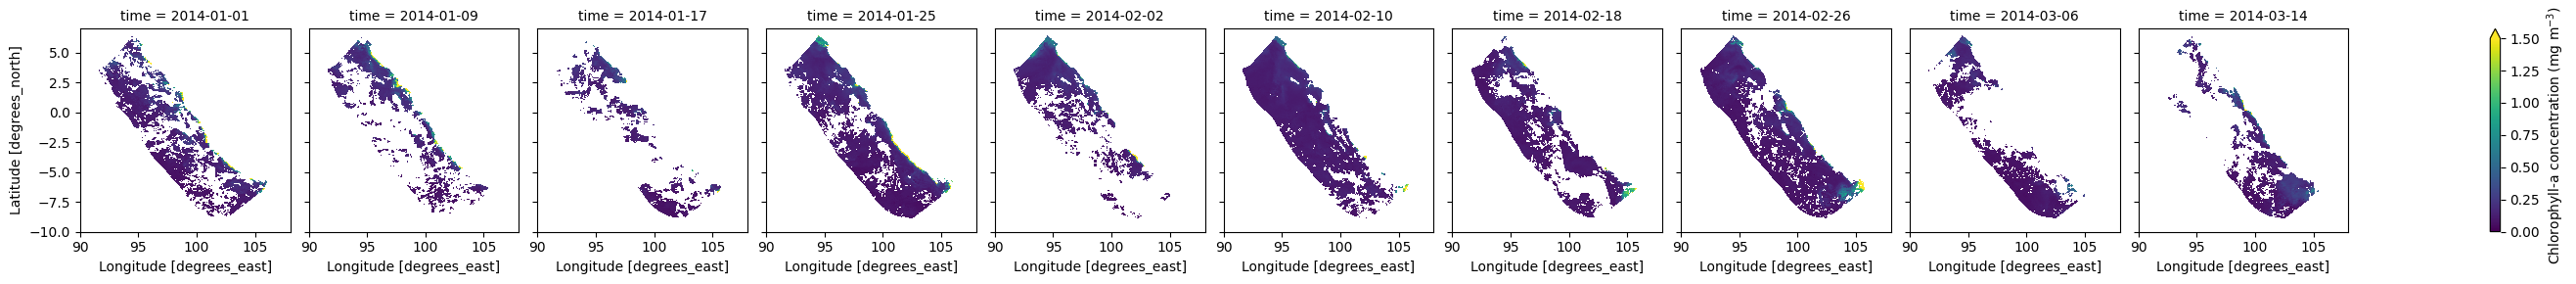

In [11]:
plot_eda_time_series_map(
    ds=ds_wpp572,
    var_name="chlor_a",
    n_data=10,
    cmap="viridis",
    col_wrap=10,
    vmin=0,
    vmax=1.5,
    cbar_label="Chlorophyll-a concentration (mg m$^{-3}$)"
)

In [12]:
# save file hasil masking
output_path = '/kaggle/working/ds_wpp572.nc'
ds_wpp572.to_netcdf(output_path)

print("Dataset ds_wpp572 berhasil disimpan di:", output_path)

Dataset ds_wpp572 berhasil disimpan di: /kaggle/working/ds_wpp572.nc


In [13]:
# save masker untuk masking-nya
output_mask_path = '/kaggle/working/mask_wpp572.npz'
# Kita simpan mask_2d beserta koordinat lat-lon aslinya sebagai cadangan
np.savez(output_mask_path, 
         mask_2d=mask_2d, 
         lons=lons, 
         lats=lats)
print("File Masker Terpisah berhasil disimpan di:", output_mask_path)

File Masker Terpisah berhasil disimpan di: /kaggle/working/mask_wpp572.npz


In [14]:
# cara buka filenya
# Membuka file dan langsung mengekstrak ke nama variabel yang sama persis
# with np.load('/kaggle/working/mask_wpp572.npz') as data:
#     mask_2d = data['mask_2d']
#     lons = data['lons']
#     lats = data['lats']